# ERP Analysis

This notebook computes and visualizes Event-Related Potentials (ERPs)
from the preprocessed EEG data.

The analysis compares brain responses across four experimental conditions:

- Auditory left
- Auditory right
- Visual left
- Visual right

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [4]:
epochs = mne.read_epochs(
    "../data/clean-epo.fif",
    preload=True
)

print(epochs)

Reading C:\Users\DELL\Desktop\eeg-cognitive-control-erp-analysis\notebooks\..\data\clean-epo.fif ...
    Found the data of interest:
        t =    -199.80 ...     499.49 ms
        0 CTF compensation matrices available
Not setting metadata
267 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 267 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~54.4 MiB, data loaded,
 'auditory/left': 63
 'auditory/right': 68
 'visual/left': 72
 'visual/right': 64>


In [5]:
print(epochs)

<EpochsFIF | 267 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~54.4 MiB, data loaded,
 'auditory/left': 63
 'auditory/right': 68
 'visual/left': 72
 'visual/right': 64>


In [10]:
auditory_left_erp = epochs["auditory/left"].average()

print(auditory_left_erp)

<Evoked | 'auditory/left' (average, N=63), -0.1998 – 0.49949 s, baseline -0.2 – 0 s, 59 ch, ~3.1 MiB>


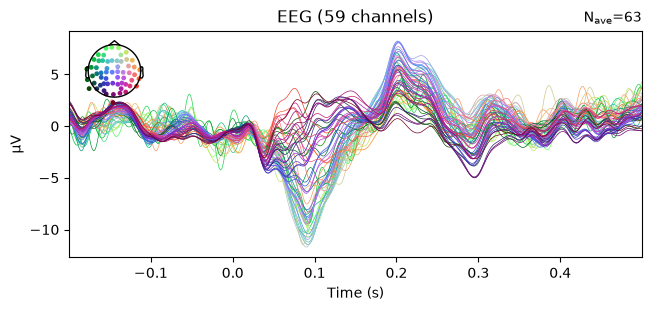

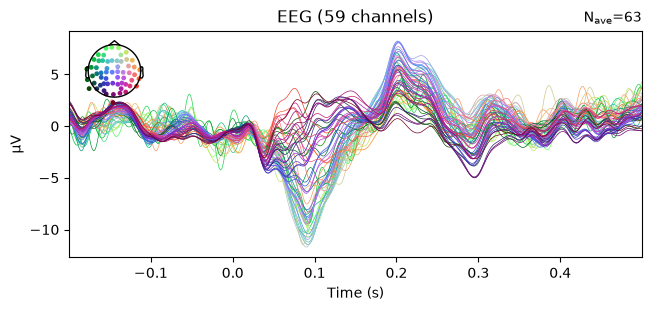

In [11]:
auditory_left_erp.plot()

In [12]:
auditory_left = epochs["auditory/left"].average()
auditory_right = epochs["auditory/right"].average()

visual_left = epochs["visual/left"].average()
visual_right = epochs["visual/right"].average()

In [13]:
print("Auditory left:", auditory_left.nave)
print("Auditory right:", auditory_right.nave)
print("Visual left:", visual_left.nave)
print("Visual right:", visual_right.nave)

Auditory left: 63
Auditory right: 68
Visual left: 72
Visual right: 64


In [14]:
auditory_erp = epochs["auditory"].average()
visual_erp = epochs["visual"].average()

print("Auditory trials:", auditory_erp.nave)
print("Visual trials:", visual_erp.nave)

Auditory trials: 131
Visual trials: 136


combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


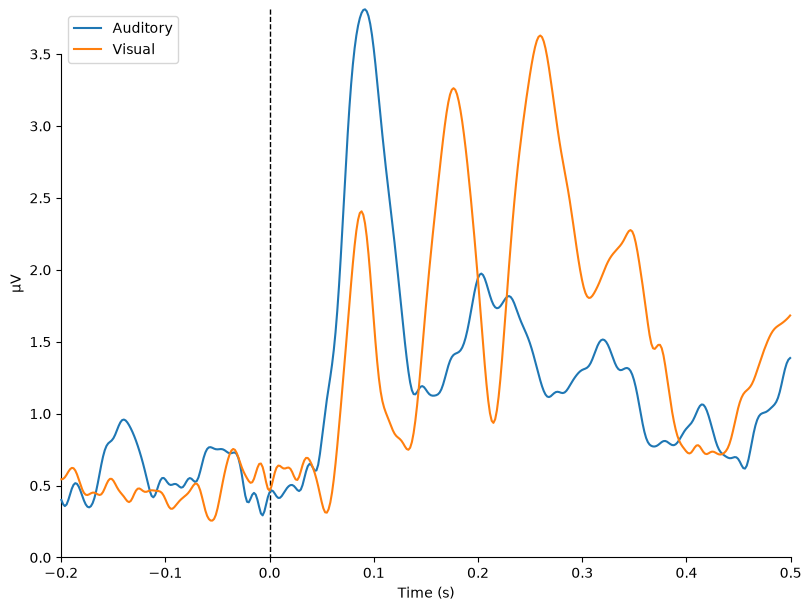

[<Figure size 800x600 with 1 Axes>]

In [15]:
mne.viz.plot_compare_evokeds({
    "Auditory": auditory_erp,
    "Visual": visual_erp
})

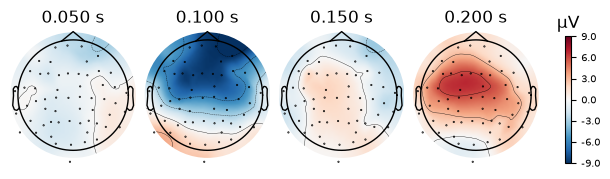

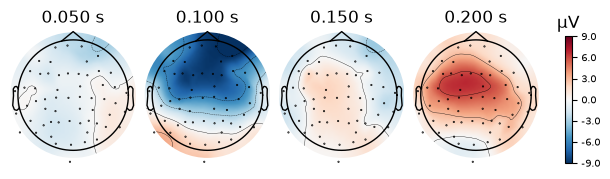

In [16]:
auditory_erp.plot_topomap(
    times=[0.05, 0.10, 0.15, 0.20],
    ch_type="eeg"
)

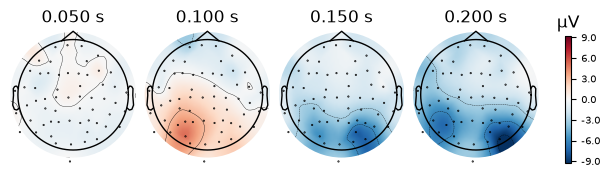

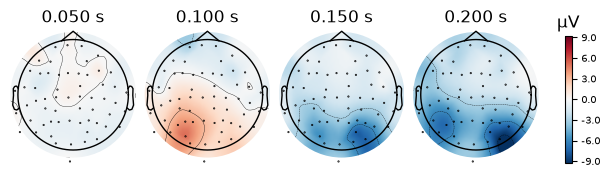

In [17]:
visual_erp.plot_topomap(
    times=[0.05, 0.10, 0.15, 0.20],
    ch_type="eeg"
)

In [18]:
print(epochs.ch_names)

['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 011', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016', 'EEG 017', 'EEG 018', 'EEG 019', 'EEG 020', 'EEG 021', 'EEG 022', 'EEG 023', 'EEG 024', 'EEG 025', 'EEG 026', 'EEG 027', 'EEG 028', 'EEG 029', 'EEG 030', 'EEG 031', 'EEG 032', 'EEG 033', 'EEG 034', 'EEG 035', 'EEG 036', 'EEG 037', 'EEG 038', 'EEG 039', 'EEG 040', 'EEG 041', 'EEG 042', 'EEG 043', 'EEG 044', 'EEG 045', 'EEG 046', 'EEG 047', 'EEG 048', 'EEG 049', 'EEG 050', 'EEG 051', 'EEG 052', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060', 'EOG 061']


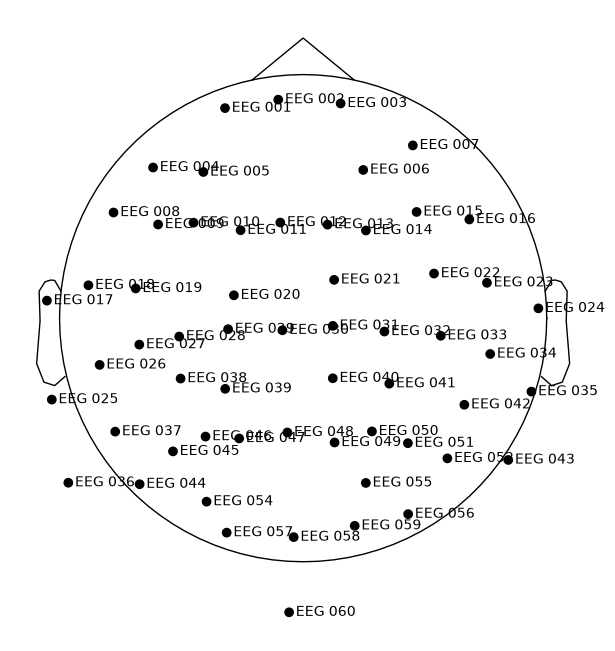

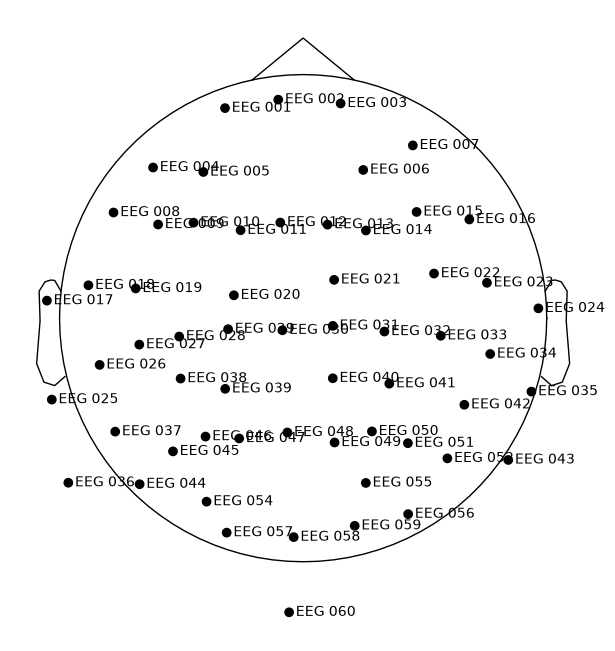

In [19]:
epochs.plot_sensors(
    ch_type="eeg",
    show_names=True
)

In [20]:
posterior_channels = ["EEG 057", "EEG 058", "EEG 059"]

combining channels using "mean"
combining channels using "mean"


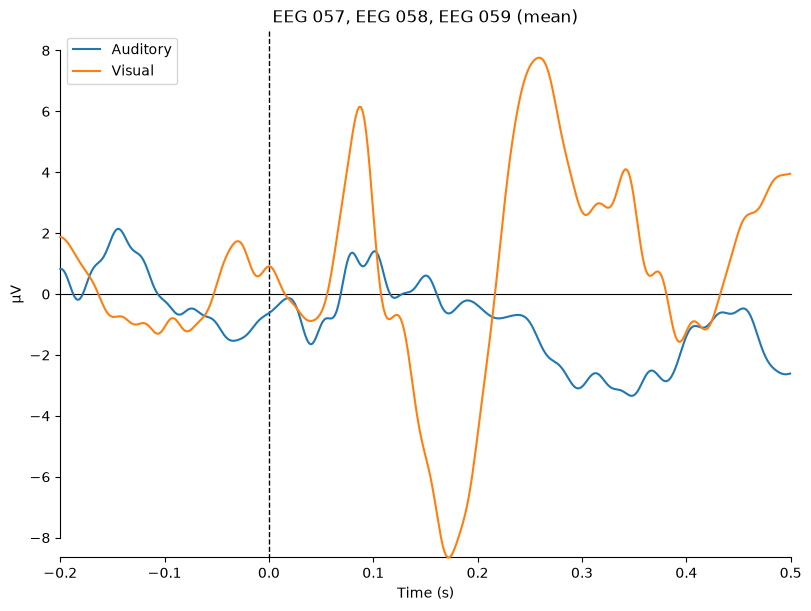

[<Figure size 800x600 with 1 Axes>]

In [21]:
mne.viz.plot_compare_evokeds(
    {
        "Auditory": auditory_erp,
        "Visual": visual_erp
    },
    picks=posterior_channels,
    combine="mean"
)

In [23]:
posterior_visual = mne.channels.combine_channels(
    visual_erp,
    groups={"Posterior": [56, 57, 58]},
    method="mean"
)

Applying baseline correction (mode: mean)


In [24]:
posterior_channels = ["EEG 057", "EEG 058", "EEG 059"]

posterior_indices = [
    visual_erp.ch_names.index(ch)
    for ch in posterior_channels
]

posterior_visual = mne.channels.combine_channels(
    visual_erp,
    groups={"Posterior": posterior_indices},
    method="mean"
)

Applying baseline correction (mode: mean)


In [25]:
channel, latency, amplitude = posterior_visual.get_peak(
    tmin=0.12,
    tmax=0.22,
    mode="neg",
    return_amplitude=True
)

print("Channel:", channel)
print("Latency:", latency * 1000, "ms")
print("Amplitude:", amplitude * 1e6, "µV")

Channel: Posterior
Latency: 171.4908912942829 ms
Amplitude: -8.649623035030661 µV


### Posterior visual response

The visual ERP was examined over a posterior region consisting of
EEG 057, EEG 058, and EEG 059.

Within the 120–220 ms post-stimulus interval, the strongest negative
peak occurred at approximately 171 ms with an amplitude of -8.65 µV.

This result quantifies the prominent posterior negative deflection
observed in the ERP waveform and scalp topographies.

In [27]:
posterior_visual = visual_erp.copy().pick(posterior_channels)
posterior_auditory = auditory_erp.copy().pick(posterior_channels)

visual_posterior_mean = posterior_visual.get_data(
    tmin=0.15,
    tmax=0.20
).mean() * 1e6

auditory_posterior_mean = posterior_auditory.get_data(
    tmin=0.15,
    tmax=0.20
).mean() * 1e6

print("Visual posterior mean amplitude:", visual_posterior_mean, "µV")
print("Auditory posterior mean amplitude:", auditory_posterior_mean, "µV")
print(
    "Difference:",
    visual_posterior_mean - auditory_posterior_mean,
    "µV"
)

Visual posterior mean amplitude: -7.211920887389062 µV
Auditory posterior mean amplitude: -0.18906527641325607 µV
Difference: -7.022855610975806 µV


### Posterior ROI analysis

A posterior region of interest was defined using EEG 057, EEG 058,
and EEG 059.

The visual ERP showed a prominent negative deflection between
150 and 200 ms after stimulus onset.

The strongest negative peak occurred at approximately 171 ms,
with an amplitude of -8.65 µV.

Mean amplitudes were also calculated over the 150–200 ms interval
for auditory and visual conditions to provide a more stable
descriptive comparison.

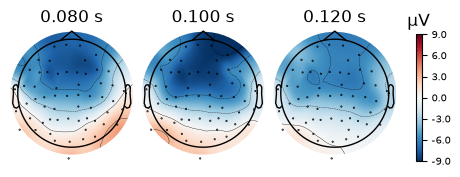

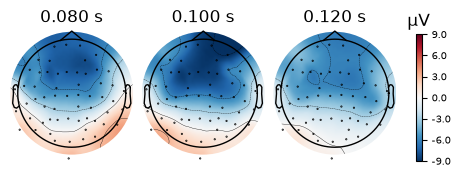

In [28]:
auditory_erp.plot_topomap(
    times=[0.08, 0.10, 0.12],
    ch_type="eeg"
)

In [29]:
central_channels = [
    "EEG 001",
    "EEG 002",
    "EEG 003"
]

combining channels using "mean"
combining channels using "mean"


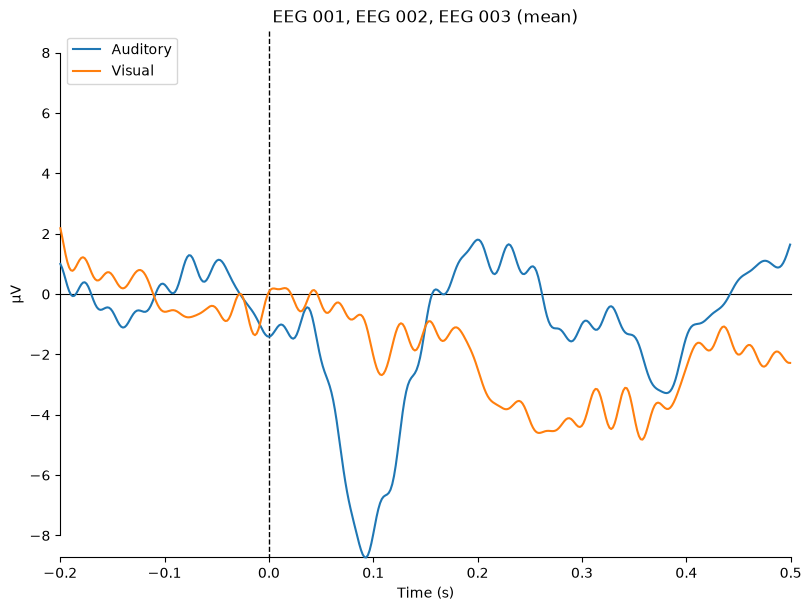

[<Figure size 800x600 with 1 Axes>]

In [30]:
mne.viz.plot_compare_evokeds(
    {
        "Auditory": auditory_erp,
        "Visual": visual_erp
    },
    picks=central_channels,
    combine="mean"
)

In [32]:
central_indices = [
    auditory_erp.ch_names.index(ch)
    for ch in central_channels
]

central_auditory = mne.channels.combine_channels(
    auditory_erp,
    groups={"Central": central_indices},
    method="mean"
)

Applying baseline correction (mode: mean)


In [33]:
channel, latency, amplitude = central_auditory.get_peak(
    tmin=0.07,
    tmax=0.13,
    mode="neg",
    return_amplitude=True
)

print("Channel:", channel)
print("Latency:", latency * 1000, "ms")
print("Amplitude:", amplitude * 1e6, "µV")

Channel: Central
Latency: 93.237766140581 ms
Amplitude: -8.729470605295207 µV


In [34]:
central_auditory_data = auditory_erp.copy().pick(central_channels)
central_visual_data = visual_erp.copy().pick(central_channels)

auditory_central_mean = central_auditory_data.get_data(
    tmin=0.08,
    tmax=0.12
).mean() * 1e6

visual_central_mean = central_visual_data.get_data(
    tmin=0.08,
    tmax=0.12
).mean() * 1e6

print("Auditory central mean:", auditory_central_mean, "µV")
print("Visual central mean:", visual_central_mean, "µV")

Auditory central mean: -7.597665351128556 µV
Visual central mean: -1.655267737371525 µV
